

<h1 style="text-align: center; font-family: 'Helvetica Neue', Arial, sans-serif; color: #1a365d; font-weight: bold; letter-spacing: 1px;">
    TS3
</h1>



<div style="text-align: center; font-family: 'Segoe UI', Helvetica, Arial, sans-serif; font-size: 16px;">
<b>Nombre y apellido:</b> Irina Polack



</div>


Sabemos que la DFT de una señal x[n] se define como:

$ X[k] = \left [ \sum_{n=0}^{N-1} x[n] \cdot e^{-j \frac{2\pi fs}{N} nk} \right]$

Siendo N la cantidad de muestras

$ \frac{fs}{N}$ es lo que se conoce como resolución espectral.
sea $ \frac{fs}{N} \cdot k = ff$, siendo k un número entero (conocido como bin), cada k me va a mostrar una muestra del espectro en la ff correspondiente, fijémosnos que si ff es un número no múltiplo de $ \frac{fs}{N}$, no habría un bin que le corresponda a esa frecuencia y en consecuencia, teóricamente, no se podría ver el espectro en esa frecuencia.
En este trabajo vamos a analizar que sucede si colocamos una determinada frecuencia, múltiplo de $ \frac{fs}{N}$ y no múltiplo.
Para eso vamos a graficar el espectro de la función:
$$x[n] = \sqrt{2} \sin\left(\frac{2\pi \cdot ff \cdot n}{f_s} + \phi\right)$$


* Frecuencia de muestreo: $f_s = 1000$  
* Número de muestras fijo: $N = 1000$
* $k0= {[\frac{N}{4}; \frac{N}{4}+ 0.25 ; \frac{N}{4}+ 0.5]}$
* Frecuencia fija: $ff = k0 \cdot \frac{fs}{N}$
* Potencia indicada: $P_x$
* Desplazamiento angular: $\phi = 0$
* Variable temporal discreta: $n \in [0, N-1]$


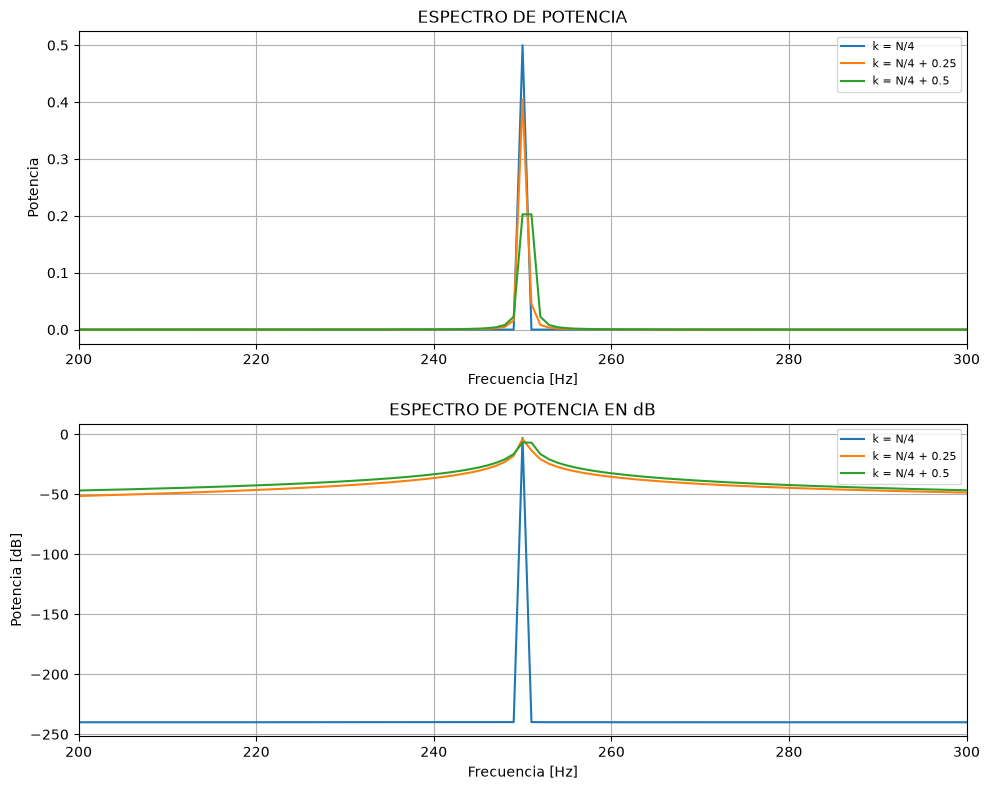

In [2]:

import numpy as np
import matplotlib.pyplot as plt



def funcion_sen(A=1, Vmed=0, ff=1, phi=0, nn=1000, fs=1000):
    tt = np.arange(nn) / fs
    xx = A * np.sin(2 * np.pi * ff * tt + phi) + Vmed
    return tt, xx
 

Ps = 1 # potencia de la senoidal (normalizada a 1W)
Amplitud = np.sqrt(2*Ps)
Vmed = 0
phi = 0
N = 1000
fs = 1000
k0 = N/4 # desp sumarle 0.25 y 0.5
ff = k0 * (fs/N)
 

tt, xx = funcion_sen(Amplitud, Vmed, ff, phi, N, fs)
 
fft_seno = np.fft.fft(xx)/N #/N para normalizarlo

modulo_sen = np.abs(fft_seno)


frecuencias = np.fft.fftfreq(N, 1/fs)
corte = N // 2
frec_nyquist = frecuencias[:corte]



plt.figure(1, figsize=(10,8))


plt.subplot(2,1,1)
plt.title("ESPECTRO DE POTENCIA")
plt.plot(frec_nyquist, (modulo_sen[:corte])**2, label='k = N/4')
plt.subplot(2,1,2)
plt.title("ESPECTRO DE POTENCIA EN dB")
plt.plot(frec_nyquist, 20*np.log10(modulo_sen[:corte] + 1e-12), label='k = N/4')


k1 = (N/4) + 0.25
f1 = k1 * (fs/N)
tt, x1 = funcion_sen(Amplitud, Vmed, f1, phi, N, fs)
fft_seno1 = np.fft.fft(x1)/N
modulo_sen1 = np.abs(fft_seno1)

plt.subplot(2,1,1)
plt.plot(frec_nyquist, (modulo_sen1[:corte])**2, label='k = N/4 + 0.25')
plt.subplot(2,1,2)
plt.plot(frec_nyquist, 20*np.log10(modulo_sen1[:corte] + 1e-12), label='k = N/4 + 0.25')


k2 = (N/4) + 0.5
f2 = k2 * (fs/N)
tt, x2 = funcion_sen(Amplitud, Vmed, f2, phi, N, fs)
fft_seno2 = np.fft.fft(x2)/N
modulo_sen2 = np.abs(fft_seno2)

plt.subplot(2,1,1)
plt.plot(frec_nyquist, (modulo_sen2[:corte])**2, label='k = N/4 + 0.5')
plt.subplot(2,1,2)
plt.plot(frec_nyquist, 20*np.log10(modulo_sen2[:corte] + 1e-12), label='k = N/4 + 0.5')


plt.subplot(2,1,1)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia")
plt.legend(fontsize=8)
plt.grid(True)
plt.xlim(200, 300)

plt.subplot(2,1,2)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia [dB]")
plt.legend(fontsize=8)
plt.grid(True)
plt.xlim(200, 300)
plt.tight_layout()
plt.show()

$$\textbf{Análisis:}$$

$$\textbf{Caso 1: $k_0 = 250$}$$

Véase que cuando $ff = \frac{N}{4} \cdot \frac{f_s}{N} = \frac{f_s}{4} = \frac{1000}{4} = 250\text{ Hz}$, la señal discreta queda expresada como:
$$x[n] = \sqrt{2} \sin\left(\frac{2\pi \cdot 250 \cdot n}{1000}\right)$$

Al expandir $x[n]$ en su forma exponencial compleja mediante la fórmula de Euler:
$$x[n] = \left(\frac{\sqrt{2}}{2j}\right) \left[ e^{j \frac{2\pi \cdot 250 \cdot n}{1000}} - e^{-j \frac{2\pi \cdot 250 \cdot n}{1000}} \right]$$

Sustituyendo en la definición de la DFT:
$$X[k] = \sum_{n=0}^{N-1} x[n] \cdot e^{-j\frac{2\pi}{1000} k n}$$
$$X[k] = \frac{\sqrt{2}}{2j} \sum_{n=0}^{N-1} \left[ e^{-j\frac{2\pi}{1000}(k - 250)n} - e^{-j\frac{2\pi}{1000}(k + 250)n} \right]$$

Utilizando la propiedad de ortogonalidad del Twiddle Factor para $N = 1000$:
$$\sum_{n=0}^{N-1} e^{-j\frac{2\pi}{N}(k - k_0)n} = N \cdot \delta[k - k_0]$$

Obtenemos:
$$X[k] = \frac{\sqrt{2} \cdot 1000}{2j} \cdot \delta[k - 250] - \frac{\sqrt{2} \cdot 1000}{2j} \cdot \delta[k - 750]$$

Al normalizar por $N = 1000$, la DFT normalizada $X_n[k] = \frac{X[k]}{N}$ resulta:
$$X_n[k] = \frac{\sqrt{2}}{2j} \delta[k - 250] - \frac{\sqrt{2}}{2j} \delta[k - 750]$$

Toda la energía de la señal se concentra exclusivamente en las deltas correspondientes a los bins $k = 250$ y $k = 750$.

$$ \textbf{Caso 2: $k_0 = 250,25$}$$

Véase que cuando $ff = \left(\frac{N}{4} + 0,25\right) \cdot \frac{f_s}{N} = 250,25\text{ Hz}$:
$$x[n] = \sqrt{2} \sin\left(\frac{2\pi \cdot 250,25 \cdot n}{1000}\right)$$

Al aplicar la DFT:
$$X[k] = \frac{\sqrt{2}}{2j} \sum_{n=0}^{N-1} \left[ e^{-j\frac{2\pi}{1000}(k - 250,25)n} - e^{-j\frac{2\pi}{1000}(k + 250,25)n} \right]$$

Como la frecuencia $ff = 250,25\text{ Hz}$ no es un múltiplo entero de la resolución espectral ($\frac{f_s}{N} = 1\text{ Hz}$), el valor $k_0 = 250,25$ no coincide con ningún índice discreto $k \in \mathbb{Z}$. Por lo tanto, la sumatoria no se simplifica en un impulso de Kronecker (delta), sino en el núcleo de Dirichlet (sinc discreta).

Al no caer exactamente en un bin, la energía de la señal se "desparrama" o distribuye a lo largo de todo el espectro (fenómeno conocido como \textit{leakage} o fuga espectral). En el gráfico en dB se observa un piso cercano a $-50\text{ dB}$ (a diferencia del Caso 1 con piso en $-250\text{ dB}$ aproximadamente), evidenciando la presencia de energía en bins alejados del tono principal.

$$\textbf{Caso 3: $k_0 = 250,50$}$$

Véase que cuando $ff = \left(\frac{N}{4} + 0,50\right) \cdot \frac{f_s}{N} = 250,50\text{ Hz}$:
$$x[n] = \sqrt{2} \sin\left(\frac{2\pi \cdot 250,50 \cdot n}{1000}\right)$$

Al evaluar la DFT:
$$X[k] = \frac{\sqrt{2}}{2j} \sum_{n=0}^{N-1} \left[ e^{-j\frac{2\pi}{1000}(k - 250,50)n} - e^{-j\frac{2\pi}{1000}(k + 250,50)n} \right]$$

Al igual que en el caso anterior, $k_0 = 250,50 \notin \mathbb{Z}$, por lo que tampoco existe un bin exacto para esta frecuencia y ocurre la fuga espectral. 

Un aspecto notable en el espectro de potencia lineal es que este caso presenta el pico más bajo de los tres. Esto sucede porque la frecuencia $250,50\text{ Hz}$ se encuentra exactamente en el punto medio entre los dos bins discretos más cercanos ($k = 250$ y $k = 251$). Al estar a la máxima distancia posible de un bin entero, la energía se reparte de forma equitativa entre ambos, reduciendo el valor del pico en comparación con $k_0 = 250,25$, que estaba más cerca del bin $250$.

<b> Identidad de Parseval y potencia </b>

La identidad de Parseval discreta nos dice que:
$$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$
siendo $$X[k]$$ la DFT de $$x[n]$$
si recordamos la definición de potencia del principio:
$$P_x = \frac{1}{N} \sum_{n=0}^{N - 1} \vert{}x[n]\vert{}^2$$
para una señal períodica
esto quiere decir que con la identidad de parseval, gracias a la linealidad de las sumatorias, si multiplicamos por $$\frac{1}{N}$$ si la función es periódica, podemos aplicar la identidad de parseval en el dominio de frecuencias y obtener así la potencia.
$$P_x = \frac{1}{N^2} \sum_{k=0}^{N - 1} \vert{}X[k]\vert{}^2$$
Vamos a probar eso aplicandole a cada caso Parseval y calculando también la potencia en el tiempo


In [3]:
# Potencia calculada en el tiempo:
potencia_tiempo = np.mean(xx**2)
potencia_tiempo1 = np.mean(x1**2)
potencia_tiempo2 = np.mean(x2**2)

# Potencia calculada desde la FFT (Parseval):
potencia_frecuencia = np.sum(np.abs(fft_seno)**2)
potencia_frecuencia1 = np.sum(np.abs(fft_seno1)**2)
potencia_frecuencia2 = np.sum(np.abs(fft_seno2)**2)

print(f"Potencia en el tiempo 0: {potencia_tiempo}")
print(f"Potencia en el tiempo 1: {potencia_tiempo1}")
print(f"Potencia en el tiempo 2: {potencia_tiempo2}")


print(f"Potencia en frecuencia 0 (Parseval): {potencia_frecuencia}")
print(f"Potencia en frecuencia 1 (Parseval): {potencia_frecuencia1}")
print(f"Potencia en frecuencia 2 (Parseval): {potencia_frecuencia2}")


Potencia en el tiempo 0: 1.0000000000000002
Potencia en el tiempo 1: 0.9989999999999998
Potencia en el tiempo 2: 1.0000000000000004
Potencia en frecuencia 0 (Parseval): 1.0000000000000002
Potencia en frecuencia 1 (Parseval): 0.9989999999999999
Potencia en frecuencia 2 (Parseval): 1.0000000000000007


$$\textbf{Análisis:}$$

Vease que los casos de potencia en el tiempo coinciden con los calculados en frecuencia.
También se ve que el caso 0, el caso 1 y el caso 2 son prácticamente iguales, probando que aunque haya derrame espectral la potencia se conserva, lo que cambia es la concentración en cada bin.

$$\textbf{Zero-padding}$$
Por último vamos a probar el fenómeno de zero-padding.
Se trata de rellenar la ventana implícita, sin agregar información.
Supongamos que tomamos N muestras, al hacerlo nuestra resolución espectral es de $ \frac{fs}{N}$, ahora que pasa si decido que de esas 1000 muestras que incorporé voy a incorporar 9N más, pero estos van a ser todos ceros.
Se puede observar que no estamos agregando ningún tipo de información, pero nos mejora la resolución espectral, ya que ahora:
$ \frac{fs}{10N}$, eso significa que la separación de cada bin es mucho menor y que por lo tanto, en los casos que venimos analizando, cuando ff no sea un entero no vamos a tener el fenómeno de derrame espectral ya que ahora la  resolución espectral=$ \frac{1000}{10000}=0,1$

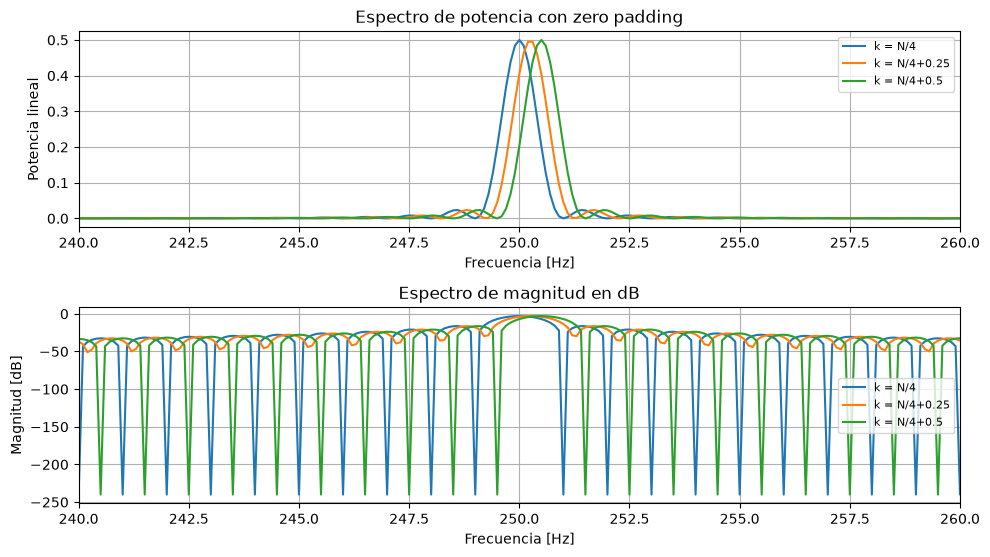

In [6]:
import numpy as np
import matplotlib.pyplot as plt
N=1000
# Asumiendo que 'N', 'fs', 'xx', 'x1', 'x2' ya están definidos previamente
zeros = np.zeros(9 * N)
xx_zeros = np.concatenate((xx, zeros))
x1_zeros = np.concatenate((x1, zeros))
x2_zeros = np.concatenate((x2, zeros))

N_pad = N + 9 * N  # 10*N muestras

frecuencias_pad = np.fft.fftfreq(N_pad, 1 / fs)
corte_pad = N_pad // 2
frec_nyquist_pad = frecuencias_pad[:corte_pad]

# Normalización por el total de muestras con padding (N_pad)
fft_xxz = (1/N)*np.fft.fft(xx_zeros)
fft_x1z =  (1/N)*np.fft.fft(x1_zeros)
fft_x2z = (1/N)* np.fft.fft(x2_zeros)


plt.figure(figsize=(10, 8))


plt.subplot(3, 1, 1)
plt.plot(frec_nyquist_pad, np.abs(fft_xxz[:corte_pad])**2, label='k = N/4')
plt.plot(frec_nyquist_pad, np.abs(fft_x1z[:corte_pad])**2, label='k = N/4+0.25')
plt.plot(frec_nyquist_pad, np.abs(fft_x2z[:corte_pad])**2, label='k = N/4+0.5')
plt.title("Espectro de potencia con zero padding")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Potencia lineal")
plt.legend(fontsize=8)
plt.grid(True)
plt.xlim(240, 260)


plt.subplot(3, 1, 2)

eps = 1e-12
plt.plot(frec_nyquist_pad, 20 * np.log10(np.maximum(np.abs(fft_xxz[:corte_pad]), eps)), label='k = N/4')
plt.plot(frec_nyquist_pad, 20 * np.log10(np.maximum(np.abs(fft_x1z[:corte_pad]), eps)), label='k = N/4+0.25')
plt.plot(frec_nyquist_pad, 20 * np.log10(np.maximum(np.abs(fft_x2z[:corte_pad]), eps)), label='k = N/4+0.5')
plt.title("Espectro de magnitud en dB")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.legend(fontsize=8)
plt.grid(True)
plt.xlim(240, 260)



plt.tight_layout()
plt.show()

Se puede ver como ahora si se ven todos los espectros de potencia iguales, tanto en altura como en ancho, la única diferencia es el desplazamiento del pico a causa del valor de ff.
Esto sucede ya que en k=$\frac{N}{4},  ff=250$, en k=$\frac{N}{4}+0,25,  ff=250,25$ y en k=$\frac{N}{4}+0,50,  ff=250,50$, esto hace que se vean desplazadas una de la otra en 0,25.


$$\textbf{Conclusión:}$$

En este trabajo se analizó que cuando utilizo una frecuencia fija que no es múltiplo de $\frac{fs}{N}$ la potencia se desparrama por el resto del espectro (spectral leakage), y que este efecto se puede eliminar utilizando cero padding (aumentando la cantidad de muestras con zero), resulta una forma muy efectiva para aumentar la resolución del espectro y evitar derrame espectral.